In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor

In [2]:
df = pd.read_csv("after_houseprice_dataset.csv")
print(df.head())

   area_sqft  bedrooms  bathrooms  location_score  house_price_inr
0       1973         5          4             7.6         40275084
1       1560         3          3             6.3         26812029
2       2071         4          3             5.8         29315677
3       2640         5          3             7.7         47712959
4       1498         3          3             3.8         17724566


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   area_sqft        4200 non-null   int64  
 1   bedrooms         4200 non-null   int64  
 2   bathrooms        4200 non-null   int64  
 3   location_score   4200 non-null   float64
 4   house_price_inr  4200 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 164.2 KB


In [4]:
df.describe()

,area_sqft,bedrooms,bathrooms,location_score,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,1667.357381,3.696667,2.827381,5.611429,2.364189e+07
std,630.336132,1.574199,1.153585,2.140880,1.239279e+07
min,450.000000,1.000000,1.000000,1.000000,8.000000e+05
25%,1226.750000,3.000000,2.000000,4.000000,1.425969e+07
50%,1660.000000,4.000000,3.000000,5.700000,2.214500e+07
75%,2084.250000,5.000000,4.000000,7.300000,3.096090e+07
max,4202.000000,7.000000,6.000000,10.000000,7.611172e+07


In [5]:
df.shape

(4200, 5)

In [6]:
feature_cols = ["area_sqft","bedrooms","bathrooms","location_score"]
X = df[feature_cols].values        # features matrix (n,4)
y = df["house_price_inr"].values   # target vector (n,)


In [7]:
print(X.shape)
print(y.shape)

(4200, 4)
(4200,)


In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [9]:
reg = LinearRegression()
reg.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
print(reg.coef_)
print(reg.intercept_)

[  14152.84053639  241276.93163323  159655.7409099  3406961.20773185]
-20427403.114161875


In [11]:
y_pred = reg.predict(X_test)
r2_score(y_test,y_pred)

0.917493627255741

In [12]:

class MBGDRegressor:
    
    def __init__(self,batch_size,learning_rate=0.01,epochs=100):
        
        self.coef_ = None
        self.intercept_ = None
        self.lr = learning_rate
        self.epochs = epochs
        self.batch_size = batch_size
        
    def fit(self,X_train,y_train):
        # init your coefs
        self.intercept_ = 0
        self.coef_ = np.ones(X_train.shape[1])
        
        for i in range(self.epochs):
            
            for j in range(int(X_train.shape[0]/self.batch_size)):
                
                idx = random.sample(range(X_train.shape[0]),self.batch_size)
                
                y_hat = np.dot(X_train[idx],self.coef_) + self.intercept_
                #print("Shape of y_hat",y_hat.shape)
                intercept_der = -2 * np.mean(y_train[idx] - y_hat)
                self.intercept_ = self.intercept_ - (self.lr * intercept_der)

                coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
                self.coef_ = self.coef_ - (self.lr * coef_der)
        
        print(self.intercept_,self.coef_)
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_

In [13]:
mbr = MBGDRegressor(batch_size=int(X_train.shape[0]/50),learning_rate=0.01,epochs=100)

In [14]:
mbr.fit(X_train,y_train)

C:\Users\BAPS\AppData\Local\Temp\ipykernel_17016\3368060143.py:27: RuntimeWarning: overflow encountered in multiply
  coef_der = -2 * np.dot((y_train[idx] - y_hat),X_train[idx])
C:\Users\BAPS\AppData\Local\Temp\ipykernel_17016\3368060143.py:28: RuntimeWarning: invalid value encountered in subtract
  self.coef_ = self.coef_ - (self.lr * coef_der)


nan [nan nan nan nan]


In [15]:
y_pred = mbr.predict(X_test)

In [16]:
sgd = SGDRegressor(learning_rate='constant',eta0=0.1)

In [17]:
batch_size = 35

for i in range(100):
    
    idx = random.sample(range(X_train.shape[0]),batch_size)
    sgd.partial_fit(X_train[idx],y_train[idx])

In [18]:
sgd.coef_

array([ 9.71026005e+13,  1.13394983e+12, -1.49576438e+12, -8.74556600e+12])

In [19]:
sgd.intercept_

array([5.00002273e+11])

In [20]:
y_pred = sgd.predict(X_test)

In [21]:
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(0)

# Load
df = pd.read_csv("after_houseprice_dataset.csv")
X = df[["area_sqft","bedrooms","bathrooms","location_score"]].values
y = df[["house_price_inr"]].values  # (n,1)

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Add bias column
Xb = np.hstack([np.ones((X_scaled.shape[0],1)), X_scaled])

# Hyperparameters
lr = 0.01
epochs = 300
batch_size = 32
theta = np.zeros((Xb.shape[1], 1))

def loss(Xb, y, theta):
    err = Xb @ theta - y
    return (err**2).mean() / 2

n = len(y)
for epoch in range(epochs):
    # shuffle indices each epoch
    idx = rng.permutation(n)
    Xb_shuff, y_shuff = Xb[idx], y[idx]
    for start in range(0, n, batch_size):
        end = start + batch_size
        X_batch = Xb_shuff[start:end]
        y_batch = y_shuff[start:end]
        err = X_batch @ theta - y_batch
        grad = (X_batch.T @ err) / len(y_batch)
        theta -= lr * grad
    if epoch % 50 == 0:
        print(f"{epoch:3d} loss={loss(Xb, y, theta):.2e}")

print("Final loss:", loss(Xb, y, theta))

# Predict in original feature scale
def predict(rows):
    rows = np.asarray(rows)
    rows_scaled = scaler.transform(rows)
    rows_b = np.hstack([np.ones((rows_scaled.shape[0],1)), rows_scaled])
    return (rows_b @ theta).ravel()

# Example
print("Example price:", predict([[2000,4,3,7.0]])[0])


  0 loss=3.13e+13
 50 loss=6.49e+12
100 loss=6.49e+12
150 loss=6.49e+12
200 loss=6.49e+12
250 loss=6.49e+12
Final loss: 6494221051726.616
Example price: 33136211.608088747


In [22]:
# Track loss each epoch (add inside training loop)
loss_hist = []

for epoch in range(epochs):
    idx = rng.permutation(n)
    Xb_shuff, y_shuff = Xb[idx], y[idx]
    for start in range(0, n, batch_size):
        end = start + batch_size
        X_batch = Xb_shuff[start:end]
        y_batch = y_shuff[start:end]
        err = X_batch @ theta - y_batch
        grad = (X_batch.T @ err) / len(y_batch)
        theta -= lr * grad
    loss_hist.append(loss(Xb, y, theta))   # record epoch loss
    if epoch % 50 == 0:
        print(f"{epoch:3d} loss={loss_hist[-1]:.2e}")


  0 loss=6.49e+12
 50 loss=6.49e+12
100 loss=6.49e+12
150 loss=6.49e+12
200 loss=6.49e+12
250 loss=6.49e+12


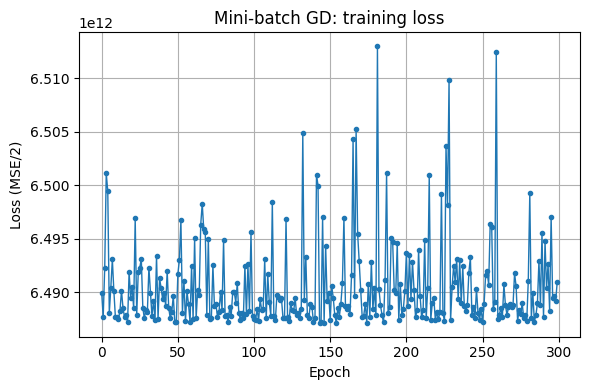

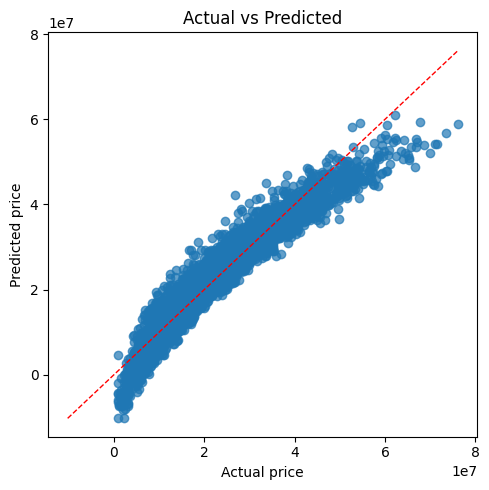

In [23]:
# Plots
import matplotlib.pyplot as plt

# 1) Loss curve
plt.figure(figsize=(6,4))
plt.plot(loss_hist, marker=".", lw=1)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE/2)")
plt.title("Mini-batch GD: training loss")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2) Predicted vs actual scatter
y_pred = predict(X)  # uses helper defined earlier
plt.figure(figsize=(5,5))
plt.scatter(y, y_pred, alpha=0.7)
lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
plt.plot(lims, lims, "r--", lw=1)  # 45° reference line
plt.xlabel("Actual price")
plt.ylabel("Predicted price")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()


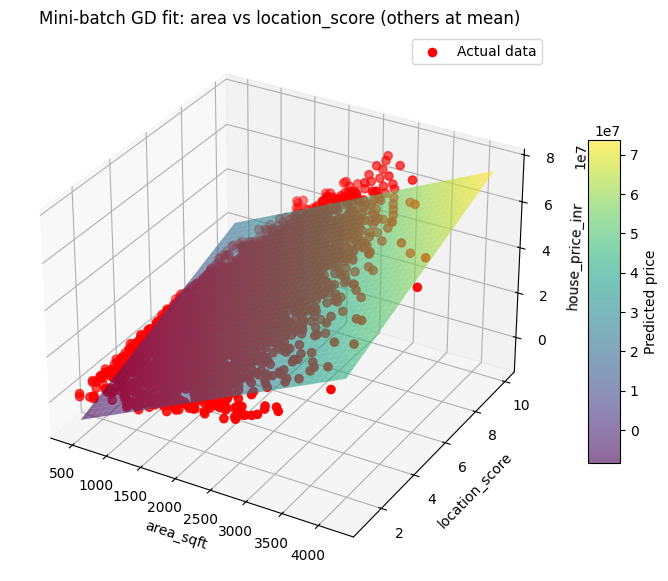

In [24]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Fix two features at their mean to view a clean 2D surface
mean_bed = df.bedrooms.mean()
mean_bath = df.bathrooms.mean()

area_grid = np.linspace(df.area_sqft.min(), df.area_sqft.max(), 40)
loc_grid  = np.linspace(df.location_score.min(), df.location_score.max(), 40)
A, L = np.meshgrid(area_grid, loc_grid)

grid_rows = np.c_[A.ravel(),
                  np.full(A.size, mean_bed),
                  np.full(A.size, mean_bath),
                  L.ravel()]

Z = predict(grid_rows).reshape(A.shape)  # predicted prices

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

# Model surface
surf = ax.plot_surface(A, L, Z, cmap="viridis", alpha=0.6, linewidth=0, antialiased=True)

# Actual data points
ax.scatter(df.area_sqft, df.location_score, df.house_price_inr,
           color="red", s=35, label="Actual data", depthshade=True)

ax.set_xlabel("area_sqft")
ax.set_ylabel("location_score")
ax.set_zlabel("house_price_inr")
ax.set_title("Mini-batch GD fit: area vs location_score (others at mean)")
ax.legend()
fig.colorbar(surf, shrink=0.6, aspect=10, label="Predicted price")
plt.show()
